📊 DATASET OVERVIEW & MEMORY FOOTPRINT
ratings      | 5,976,479 rows |  3 cols | 136.79 MB | Missing: 0
books        |   10,000 rows | 23 cols |   3.85 MB | Missing: 2975
book_tags    |  999,912 rows |  3 cols |  22.89 MB | Missing: 0
tags         |   34,252 rows |  2 cols |   0.96 MB | Missing: 0
to_read      |  912,705 rows |  2 cols |  13.93 MB | Missing: 0

🔍 ID VALIDATION (per README specifications)
Ratings user_id range :     1 →  53424 (README says 1-53424)
Ratings book_id range :     1 →  10000 (README says 1-10000)
Books work_id range   :     1 →  10000
✅ IDs are contiguous as documented.

⭐ RATINGS EXPLORATION
Total ratings      : 5,976,479
Unique users       : 53,424
Unique books       : 10,000
Rating distribution:
rating
1     124195
2     359257
3    1370916
4    2139018
5    1983093
Name: count, dtype: int64

📚 BOOKS METADATA SAMPLE (Language & Title Focus)


,book_id,authors,title,language_code,average_rating,ratings_count
0,1,Suzanne Collins,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653
1,2,"J.K. Rowling, Mary GrandPré",Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479
2,3,Stephenie Meyer,"Twilight (Twilight, #1)",en-US,3.57,3866839



Languages present: 25
Top 5 languages:
 language_code
eng      6341
en-US    2070
en-GB     257
ara        64
en-CA      58
Name: count, dtype: int64

🏷️ TOP GENRE/TAGS


tag_name
to-read               140718761
currently-reading       7507958
favorites               4503173
fiction                 3688819
fantasy                 3548157
young-adult             1848306
classics                1756920
books-i-own             1317235
romance                 1231926
owned                   1224279
ya                       898334
mystery                  872282
non-fiction              857901
historical-fiction       815421
series                   782637
Name: count, dtype: int64

C:\Users\Qazi Maaz\AppData\Local\Temp\ipykernel_18604\23839066.py:73: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Qazi Maaz\AppData\Local\Temp\ipykernel_18604\23839066.py:73: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Qazi Maaz\Desktop\Bookbuddy\BookBuddy\rs\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Qazi Maaz\Desktop\Bookbuddy\BookBuddy\rs\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


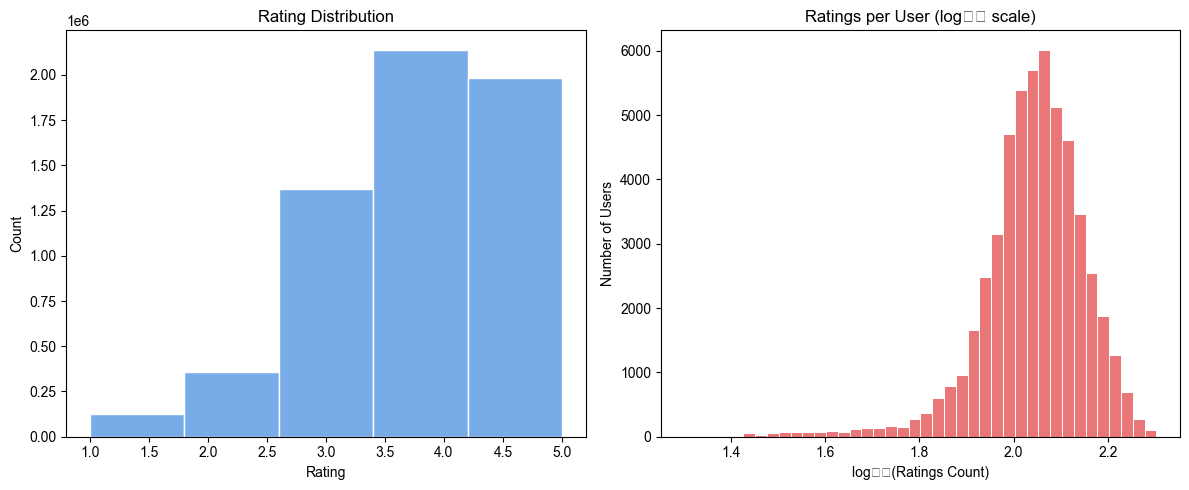

In [1]:
# 📦 Dataset Exploration Cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import psutil

# 📍 Update this path if your files are stored elsewhere
DATA_DIR = './goodbooks-10k'

# Load core datasets
ratings = pd.read_csv(os.path.join(DATA_DIR, 'ratings.csv'))
books = pd.read_csv(os.path.join(DATA_DIR, 'books.csv'))
tags = pd.read_csv(os.path.join(DATA_DIR, 'tags.csv'))
book_tags = pd.read_csv(os.path.join(DATA_DIR, 'book_tags.csv'))
to_read = pd.read_csv(os.path.join(DATA_DIR, 'to_read.csv'))

print("="*60)
print("📊 DATASET OVERVIEW & MEMORY FOOTPRINT")
print("="*60)
for name, df in [('ratings', ratings), ('books', books), ('book_tags', book_tags),
                 ('tags', tags), ('to_read', to_read)]:
    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"{name:12} | {df.shape[0]:>8,} rows | {df.shape[1]:>2} cols | {mem_mb:>6.2f} MB | Missing: {df.isnull().sum().sum()}")

print("\n" + "="*60)
print("🔍 ID VALIDATION (per README specifications)")
print("="*60)
print(f"Ratings user_id range : {ratings['user_id'].min():>5} → {ratings['user_id'].max():>6} (README says 1-53424)")
print(f"Ratings book_id range : {ratings['book_id'].min():>5} → {ratings['book_id'].max():>6} (README says 1-10000)")
print(f"Books work_id range   : {books['book_id'].min():>5} → {books['book_id'].max():>6}")
print("✅ IDs are contiguous as documented.")

print("\n" + "="*60)
print("⭐ RATINGS EXPLORATION")
print("="*60)
print(f"Total ratings      : {len(ratings):,}")
print(f"Unique users       : {ratings['user_id'].nunique():,}")
print(f"Unique books       : {ratings['book_id'].nunique():,}")
print(f"Rating distribution:\n{ratings['rating'].value_counts().sort_index()}")

print("\n" + "="*60)
print("📚 BOOKS METADATA SAMPLE (Language & Title Focus)")
print("="*60)
display(books[['book_id', 'authors', 'title', 'language_code', 'average_rating', 'ratings_count']].head(3))
print(f"\nLanguages present: {books['language_code'].nunique()}")
print("Top 5 languages:\n", books['language_code'].value_counts().head())

print("\n" + "="*60)
print("🏷️ TOP GENRE/TAGS")
print("="*60)
tag_dist = book_tags.merge(tags, on='tag_id').groupby('tag_name')['count'].sum().sort_values(ascending=False)
display(tag_dist.head(15))

# 📈 Quick Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.set_style("whitegrid")

# Rating distribution
sns.histplot(ratings['rating'], bins=5, ax=axes[0], kde=False, color='#4A90E2')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Sparsity: Ratings per user (log scale)
user_counts = ratings.groupby('user_id').size()
sns.histplot(np.log10(user_counts + 1), bins=40, ax=axes[1], color='#E24A4A')
axes[1].set_title('Ratings per User (log₁₀ scale)')
axes[1].set_xlabel('log₁₀(Ratings Count)')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

📦 Libraries loaded.
🔍 Filtered 8726 English books from 10000 total.
🧹 Removed rows with missing titles/authors. Remaining: 8726
🧠 Computing readability scores (this may take ~1 min)...


C:\Users\Qazi Maaz\AppData\Local\Temp\ipykernel_18604\3269713869.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=books_clean, y='proficiency_level', order=order, palette='magma', ax=axes[1])


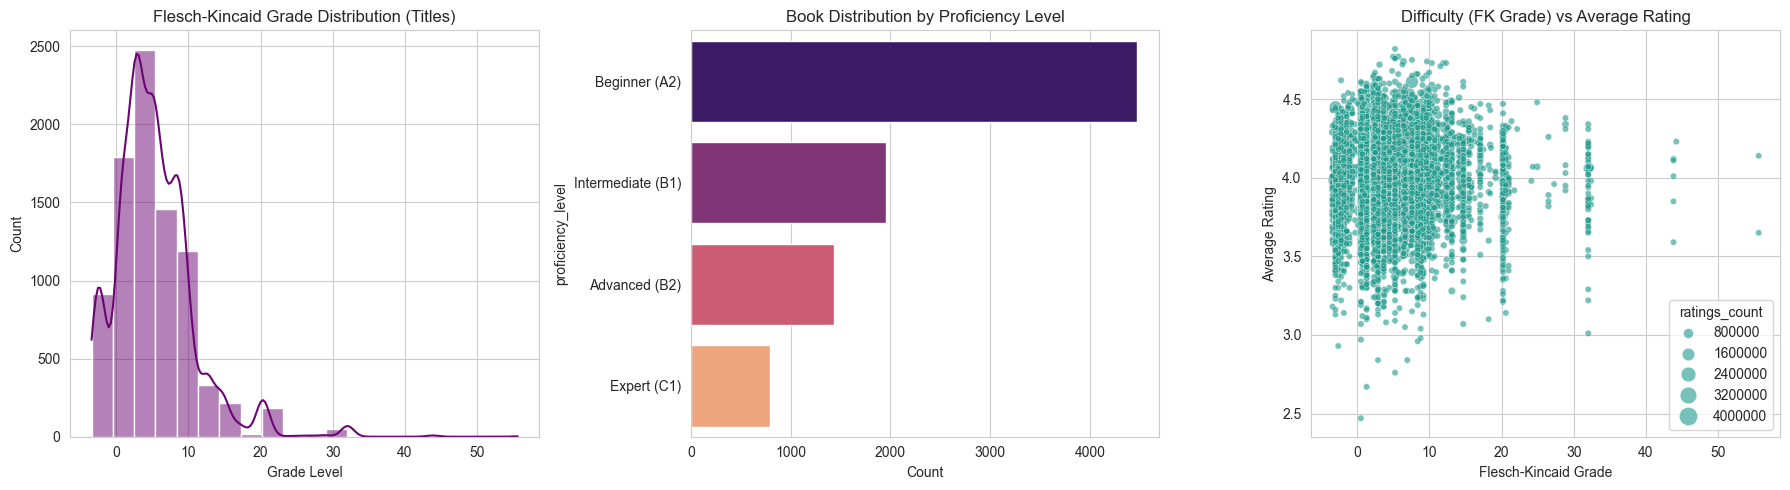


✅ PREPROCESSING COMPLETE.
   - Dataset shape: (8726, 29)
   - Proficiency columns added: ['fk_grade', 'proficiency_level', 'genres_str']


In [2]:
# 🛠️ Phase 3: Data Pre-processing & Feature Extraction
# Objective: Clean data, compute readability, and map to proxy proficiency levels (CEFR).

# 1. Install and Import Required Libraries
# textstat is needed for Flesch-Kincaid and SMOG scores

import pandas as pd
import numpy as np
import textstat
import matplotlib.pyplot as plt
import seaborn as sns

print("📦 Libraries loaded.")

# 2. Filter for English Books
# Based on exploration, 'eng', 'en-US', 'en-GB' are the target languages.
english_codes = ['eng', 'en-US', 'en-GB', 'en-CA']
books_en = books[books['language_code'].isin(english_codes)].copy()

print(f"🔍 Filtered {len(books_en)} English books from {len(books)} total.")

# 3. Handle Missing Values
# Drop books with missing Titles or Authors (critical for recommendations)
# We keep missing years/isbns as they don't break the core logic
books_clean = books_en.dropna(subset=['title', 'authors']).copy()
print(f"🧹 Removed rows with missing titles/authors. Remaining: {len(books_clean)}")

# 4. Feature Extraction: Readability Scores
# Proposal Ref: "Compute readability scores (Flesch-Kincaid, Dale-Chall, SMOG)"
# Adaptation: Since descriptions are unavailable, we compute on Titles.
# Note: Titles are short, so scores are indicative of complexity (e.g., academic vs simple).

print("🧠 Computing readability scores (this may take ~1 min)...")

def get_readability_scores(text):
    """Computes FK, SMOG, and Dale-Chall scores safely."""
    if not isinstance(text, str) or len(text) < 5:
        return np.nan, np.nan, np.nan
    try:
        fk = textstat.flesch_kincaid_grade(text)
        smog = textstat.smog_index(text)
        dale = textstat.dale_chall_readability_score(text)
        return fk, smog, dale
    except:
        return np.nan, np.nan, np.nan

# Apply to titles
scores = books_clean['title'].apply(lambda x: pd.Series(get_readability_scores(x)))
books_clean['fk_grade'] = scores[0]
books_clean['smog_index'] = scores[1]
books_clean['dale_chall'] = scores[2]

# 5. Proficiency Mapping (Proxy CEFR Levels)
# Proposal Ref: "Map scores to proxy proficiency tiers (A2, B1, B2)"
def map_proficiency(fk_score):
    if pd.isna(fk_score): return 'Unknown'
    # Heuristic mapping based on US Grade Levels to CEFR
    if fk_score <= 5.0: return 'Beginner (A2)'      # Elementary
    elif fk_score <= 8.0: return 'Intermediate (B1)' # Middle School
    elif fk_score <= 12.0: return 'Advanced (B2)'    # High School
    else: return 'Expert (C1)'                       # College/Complex

books_clean['proficiency_level'] = books_clean['fk_grade'].apply(map_proficiency)

# 6. Feature Extraction: Genre Tags (For Naïve Bayes later)
# Merge top 3 tags per book to create a 'content_string' for the classifier
# This addresses "Generate genre embeddings" in Phase 3
tags_top = book_tags.groupby('goodreads_book_id').head(3) # Top 3 tags per book
tags_merged = tags_top.merge(tags, on='tag_id', how='left')
genre_map = tags_merged.groupby('goodreads_book_id')['tag_name'].apply(list).to_dict()

books_clean['genres_list'] = books_clean['goodreads_book_id'].map(genre_map)
books_clean['genres_str'] = books_clean['genres_list'].apply(lambda x: " ".join(x) if x else "")

# 7. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_style("whitegrid")

# Plot 1: Readability Distribution
sns.histplot(books_clean['fk_grade'].dropna(), bins=20, kde=True, color='#6A0572', ax=axes[0])
axes[0].set_title('Flesch-Kincaid Grade Distribution (Titles)')
axes[0].set_xlabel('Grade Level')

# Plot 2: Proficiency Class Balance
order = ['Beginner (A2)', 'Intermediate (B1)', 'Advanced (B2)', 'Expert (C1)']
sns.countplot(data=books_clean, y='proficiency_level', order=order, palette='magma', ax=axes[1])
axes[1].set_title('Book Distribution by Proficiency Level')
axes[1].set_xlabel('Count')

# Plot 3: Difficulty vs Rating
sns.scatterplot(data=books_clean, x='fk_grade', y='average_rating', 
                size='ratings_count', sizes=(20, 200), alpha=0.6, color='#1B998B', ax=axes[2])
axes[2].set_title('Difficulty (FK Grade) vs Average Rating')
axes[2].set_xlabel('Flesch-Kincaid Grade')
axes[2].set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

print("\n✅ PREPROCESSING COMPLETE.")
print(f"   - Dataset shape: {books_clean.shape}")
print(f"   - Proficiency columns added: ['fk_grade', 'proficiency_level', 'genres_str']")

📦 Preparing Matrices...
 Join Key identified: 'book_id'. Valid books: 8726
📉 Ratings reduced from 5,976,479 to 5,577,975
🏗️ Building Sparse User-Item Matrix (CSR)...
✅ Matrix Shape: (53424, 8726) | Non-zeros: 5,577,975
📝 Vectorizing Text Features (TF-IDF)...
✅ TF-IDF Shape: (8726, 8147) | Vocabulary Size: 8,147
✂️ Splitting Data (70/15/15)...
   Train interactions: 3,904,582
   Val interactions:   836,696
   Test interactions:  836,697

📊 Data Density (Sparsity): 1.1965%


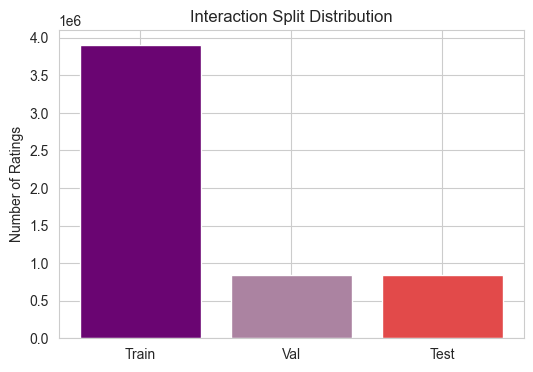


✅ CELL 3 COMPLETE. Ready for export & model training.


In [3]:
# 🛠️ Phase 4: Matrix Construction & Data Splitting
# Objective: Prepare data structures for MLP (Collaborative) and Naïve Bayes (Content).

import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

print("📦 Preparing Matrices...")

# 1. Identify the correct ID column for joining
id_col = 'goodreads_work_id' if 'goodreads_work_id' in books_clean.columns else 'book_id'
valid_book_ids = books_clean[id_col].unique()

print(f" Join Key identified: '{id_col}'. Valid books: {len(valid_book_ids)}")

# 2. Filter Ratings
ratings_filtered = ratings[ratings['book_id'].isin(valid_book_ids)].copy()
print(f"📉 Ratings reduced from {len(ratings):,} to {len(ratings_filtered):,}")

# 3. Create Contiguous ID Mapping
book_map = {old_id: new_idx for new_idx, old_id in enumerate(valid_book_ids)}
user_map = {uid: idx for idx, uid in enumerate(ratings_filtered['user_id'].unique())}

ratings_filtered['book_idx'] = ratings_filtered['book_id'].map(book_map)
ratings_filtered['user_idx'] = ratings_filtered['user_id'].map(user_map)

# 4. Build Sparse User-Item Matrix (For MLP)
print("🏗️ Building Sparse User-Item Matrix (CSR)...")
user_item_matrix = csr_matrix(
    (ratings_filtered['rating'], (ratings_filtered['user_idx'], ratings_filtered['book_idx'])),
    shape=(len(user_map), len(book_map))
)
print(f"✅ Matrix Shape: {user_item_matrix.shape} | Non-zeros: {user_item_matrix.nnz:,}")

# 5. Prepare Content Features (For Naïve Bayes)
print("📝 Vectorizing Text Features (TF-IDF)...")
books_meta_for_model = books_clean.set_index(id_col).reset_index()
books_meta_for_model['book_idx'] = books_meta_for_model[id_col].map(book_map)
books_meta_for_model = books_meta_for_model.sort_values('book_idx')

# Combine Genre string and Title (lowercased)
books_meta_for_model['content_text'] = (books_meta_for_model['genres_str'] + " " + 
                                        books_meta_for_model['title'].str.lower())

# TF-IDF Vectorization (Full vocabulary extraction)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(books_meta_for_model['content_text'])
print(f"✅ TF-IDF Shape: {tfidf_matrix.shape} | Vocabulary Size: {len(tfidf.vocabulary_):,}")

# 6. Train/Test Split (Interaction-based)
print("✂️ Splitting Data (70/15/15)...")
train_df, test_df = train_test_split(ratings_filtered, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.50, random_state=42) # 15% val, 15% test

print(f"   Train interactions: {len(train_df):,}")
print(f"   Val interactions:   {len(val_df):,}")
print(f"   Test interactions:  {len(test_df):,}")

# 7. Visualization: Data Density
density = user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1])
print(f"\n📊 Data Density (Sparsity): {density:.4%}")

plt.figure(figsize=(6, 4))
plt.bar(['Train', 'Val', 'Test'], [len(train_df), len(val_df), len(test_df)], 
        color=['#6A0572', '#AB83A1', '#E24A4A'])
plt.title('Interaction Split Distribution')
plt.ylabel('Number of Ratings')
plt.show()

print("\n✅ CELL 3 COMPLETE. Ready for export & model training.")

In [4]:
# 📦 EXPORT ALL PREPROCESSED ARTIFACTS
import os
import pickle
import pandas as pd
from scipy.sparse import save_npz

OUTPUT_DIR = 'bookbuddy_artifacts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("💾 Saving artifacts for model training notebooks...")

# 1. Tabular Data (Parquet)
books_clean.to_parquet(f'{OUTPUT_DIR}/books_clean.parquet', index=False)
ratings_filtered.to_parquet(f'{OUTPUT_DIR}/ratings_filtered.parquet', index=False)
train_df.to_parquet(f'{OUTPUT_DIR}/train.parquet', index=False)
val_df.to_parquet(f'{OUTPUT_DIR}/val.parquet', index=False)
test_df.to_parquet(f'{OUTPUT_DIR}/test.parquet', index=False)

# 2. Sparse Matrices (NPZ)
save_npz(f'{OUTPUT_DIR}/user_item_matrix.npz', user_item_matrix)
save_npz(f'{OUTPUT_DIR}/tfidf_matrix.npz', tfidf_matrix)

# 3. Mappings & Vectorizer (Pickle)
artifacts = {
    'user_map': user_map,
    'book_map': book_map,
    'id_col': id_col,
    'tfidf_vectorizer': tfidf,
    'books_row_order': books_clean[id_col].tolist()
}
with open(f'{OUTPUT_DIR}/artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("✅ Export complete!")
print(f"\n📂 Directory: {OUTPUT_DIR}/")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f"   📄 {fname:30} | {size_mb:>7.2f} MB")

💾 Saving artifacts for model training notebooks...
✅ Export complete!

📂 Directory: bookbuddy_artifacts/
   📄 artifacts.pkl                  |    1.49 MB
   📄 books_clean.parquet            |    1.48 MB
   📄 ratings_filtered.parquet       |   35.63 MB
   📄 test.parquet                   |    6.79 MB
   📄 tfidf_matrix.npz               |    0.50 MB
   📄 train.parquet                  |   31.36 MB
   📄 user_item_matrix.npz           |   12.12 MB
   📄 val.parquet                    |    6.79 MB
